

Name : **Deema Mohammed AL-Maqadma** ||
ID : **2320230766** || Presented to : **Eng. Nour Abo Rokb** || Data Science Project-Mashine Learning

---



# Data Science Project - Preprocessing, Visualization, and Machine Learning
In this notebook I will prepare my dataset, clean it, visualize it, and then apply machine learning algorithms.

In [ ]:
# Connect to my Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load my dataset
import pandas as pd
data = pd.read_csv('/content/drive/MyDrive/ai_student_impact_dataset (1).csv')
data.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,moo,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,mompo,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,TRUE,Data science,8.13,5,Allowed_With_Citation,6,24,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,FALSE,Data science,16.65,3,Allowed_With_Citation,9,77,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,FALSE,Machine learning,10.35,5,Strict_Ban,9,31,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,FALSE,NLP model,15.23,2,Allowed_With_Citation,2,85,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,FALSE,Machine learning,12.55,4,Allowed_With_Citation,4,60,3.798,100.00,Medium


In [ ]:
# Preprocessing step
# Check info and missing values
print(data.info())
print(data.isnull().sum())

# Fill missing values if needed
data = data.fillna('not available')

# Remove duplicates
data = data.drop_duplicates()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            49998 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            49995 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           49999 non-null  object 
 9   moo                         50000 non-null  object 
 10  Traditional_Study_Hours     50000 non-null  float64
 11  Perceived_AI_Dependency     50000 non-null  int64  
 12  Institutional_Policy        49998 non-null  object 
 13  Anxiety_Level_During_Exams  500

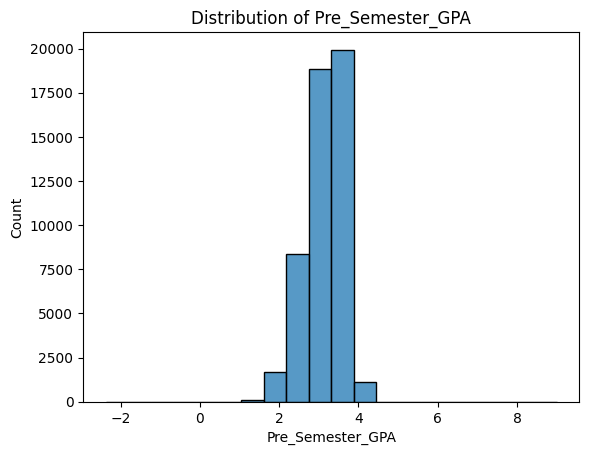

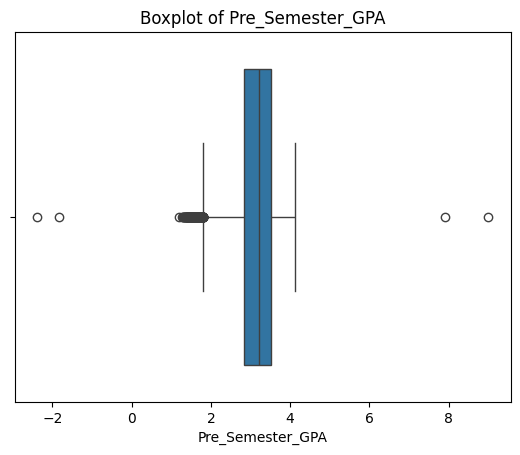

In [ ]:

# Convert Pre_Semester_GPA to numeric and drop invalid values
data['Pre_Semester_GPA'] = pd.to_numeric(data['Pre_Semester_GPA'], errors='coerce')

# Drop rows with NaN in Pre_Semester_GPA
clean_gpa = data['Pre_Semester_GPA'].dropna()

# Visualization step (corrected)
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(clean_gpa, bins=20)
plt.title("Distribution of Pre_Semester_GPA")
plt.show()

sns.boxplot(x=clean_gpa)
plt.title("Boxplot of Pre_Semester_GPA")
plt.show()

# Machine Learning Phase
Now I will apply classification and regression models on my dataset.

In [ ]:
# Classification using Burnout_Risk_Level
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Prepare features and target
X = data[['Pre_Semester_GPA','Weekly_GenAI_Hours','Traditional_Study_Hours','Skill_Retention_Score','Anxiety_Level_During_Exams']]
y = data['Burnout_Risk_Level']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5091
              precision    recall  f1-score   support

        High       0.65      0.46      0.54      2536
         Low       0.49      0.51      0.50      3269
      Medium       0.47      0.54      0.50      4195

    accuracy                           0.51     10000
   macro avg       0.54      0.50      0.51     10000
weighted avg       0.52      0.51      0.51     10000



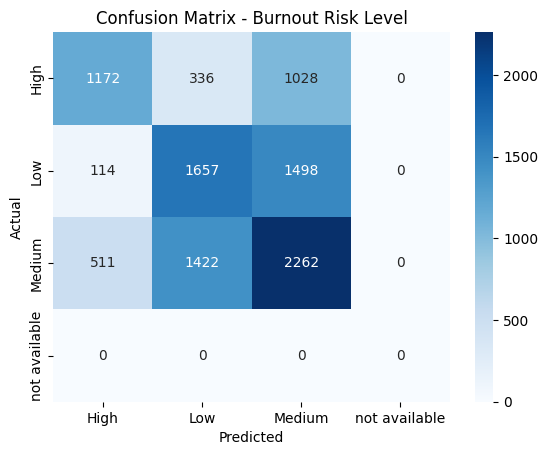

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix - Burnout Risk Level")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Clean numeric target column
data['Post_Semester_GPA'] = pd.to_numeric(data['Post_Semester_GPA'], errors='coerce')

# Select features and target
features = ['Pre_Semester_GPA','Weekly_GenAI_Hours','Traditional_Study_Hours','Skill_Retention_Score','Anxiety_Level_During_Exams']
X = data[features]
y = data['Post_Semester_GPA']

# Drop rows with NaN in either X or y
valid_data = pd.concat([X, y], axis=1).dropna()
X = valid_data[features]
y = valid_data['Post_Semester_GPA']

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train regression model
reg = LinearRegression()
reg.fit(X_train, y_train)

# Predict and evaluate
y_pred = reg.predict(X_test)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 0.032725860668147484
R2 Score: 0.8695593564761338


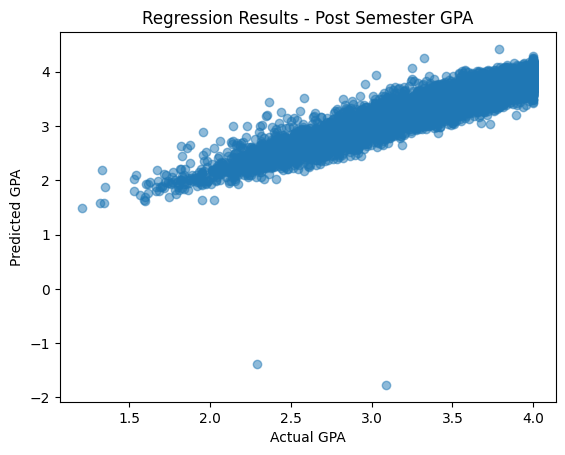

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.title("Regression Results - Post Semester GPA")
plt.show()

# Results
I applied Decision Tree classification to predict Burnout Risk Level and achieved an accuracy of about 51%.
The confusion matrix shows that the model can distinguish between High, Medium, and Low risk levels, but with moderate performance.
Then I applied Linear Regression to predict Post Semester GPA. The regression model achieved a very good R² score of 0.87, meaning it explains most of the variance in GPA values, with a low Mean Squared Error of 0.03.
The scatter plot confirms that predicted GPA values are close to the actual values.
Overall, classification gave moderate results, while regression performed strongly.